# St. Francois Mountains ca. 1466 Ma paleomagnetic pole

## Geologic context

The St. Francois Mountains (SFM) of southeastern Missouri are the exposed northeastern terminus of the ca. 1.5 to 1.3 Ga "anorogenic" granite-rhyolite province of southern Laurentia — nearly 40,000 km² of acidic volcanic and plutonic rocks (caldera-forming ignimbrites, ring intrusions, and shallow plutons) emplaced during a ca. 1.47 Ga magmatic episode (U-Pb zircon and titanite; Van Schmus et al., 1993; du Bray et al., 2021; see Age constraints). Caldera collapse (the Butler Hill and Taum Sauk calderas) produced quasi-radial tilting of the volcanic units, and the province was later intruded by the ca. 1320 Ma Skrainka-suite mafic rocks and coeval hypersolvus granites and overlain by a Cambrian boulder conglomerate — relationships that provide fold, baked-contact, and conglomerate field tests of the magnetization (Meert & Stuckey, 2002).

## Pole

This notebook recreates the SFM pole at the site level from the 18 sites (of 22 sampled) that yielded stable, consistent tilt-corrected directions (Meert & Stuckey, 2002). The conglomerate and inverse-baked-contact are described and the fold test is reproduced.

## Age constraints

The SFM igneous province was originally dated at 1476 ± 16 Ma (U-Pb zircon; Van Schmus et al., 1993), the age adopted by Meert & Stuckey (2002). Subsequent U-Pb work resolved two distinct Mesoproterozoic magmatic episodes in the terrane:

| Episode | Age | Character | Representative dated units |
|---|---|---|---|
| Older | ca. 1.48-1.45 Ga | Volumetrically dominant felsic ash-flow tuffs, rhyolite, and epizonal granite | Taum Sauk Rhyolite 1466 ± 3, Johnson's Shut-Ins Rhyolite 1464 ± 3, Cope Hollow Rhyolite 1462 ± 1 Ma (U-Pb zircon ID-TIMS; Thomas et al., 2012); many additional units, du Bray et al. (2021) |
| Younger | ca. 1.34-1.27 Ga | Compositionally bimodal: Skrainka-suite gabbro/diabase plus hypersolvus granites | Devil's Tollgate Gabbro 1323 ± 1 (U-Pb baddeleyite), Munger Granite Porphyry 1323 ± 2, Graniteville Granite 1317 ± 2 Ma (U-Pb zircon, all ID-TIMS; Thomas et al., 2012) |

The dolerites and acidic rocks carrying the paleomagnetic remanence belong to the older 1.48-1.45 Ga episode. Taking the spread of in-situ dates from that episode (du Bray et al., 2021) gives a nominal age of 1466 Ma with bounds of 1448-1484 Ma, adopted here in place of the older 1476 ± 16 Ma value. The younger episode is not the source of this pole, but its dated intrusions provide the baked-contact constraint below and are a target for developing a separate ca. 1320 Ma pole.

## References

### Paleomagnetism

- Meert, J. G., & Stuckey, W. (2002). Revisiting the paleomagnetism of the 1.476 Ga St. Francois Mountains igneous province, Missouri. *Tectonics*, 21(2), 1007. https://doi.org/10.1029/2000TC001265

### Geochronology

- du Bray, E. A., Aleinikoff, J. N., Day, W. C., Neymark, L. A., & Burgess, S. D. (2021). Petrology and geochronology of 1.48 to 1.45 Ga igneous rocks in the St. Francois Mountains terrane, southeast Missouri. U.S. Geological Survey Professional Paper 1866. https://doi.org/10.3133/pp1866
- Thomas, W. A., Tucker, R. D., Astini, R. A., & Denison, R. E. (2012). Ages of pre-rift basement and synrift rocks along the conjugate rift and transform margins of the Argentine Precordillera and Laurentia. *Geosphere*, 8(6), 1366-1383. https://doi.org/10.1130/GES00800.1
- Van Schmus, W. R., Bickford, M. E., & Sims, P. K. (1993). Transcontinental Proterozoic provinces. In J. C. Reed et al. (Eds.), *The Geology of North America, v. C-2, Precambrian: Coterminous U.S.* (pp. 171-334). Geological Society of America.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data and pole sites

Site means are loaded from `../data/1466_St_Francois_Mountains/` (rebuilt from the
audited Meert & Stuckey 2002 contribution, with signed VGPs recomputed). The pole
uses the 18 sites with a stable primary direction in tilt-corrected coordinates;
excluded are the reversed, poorly-grouped site 15, the 6-CT Cambrian conglomerate
clasts, and the ca. 1320 Ma Skrainka-suite dike / baked-contact component rows.

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1466_St_Francois_Mountains/sites.txt')
# The 18 tilt-corrected site means of the characteristic SFM remanence. Rows
# excluded from the pole — the ca. 1320 Ma Skrainka-suite dike / baked-contact
# components, the Cambrian conglomerate-test clasts (6-CT), and the reversed,
# poorly grouped site (15-TS) — are flagged result_quality='b' in the MagIC
# contribution and dropped by load_magic_sites, so no component-name filtering
# is needed.
primary = sites_tc.reset_index(drop=True)
study_lat, study_lon = 37.5, 269.5
print(f'{len(primary)} pole sites (tilt-corrected)')
primary[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95',
         'dir_n_samples', 'vgp_lat', 'vgp_lon']]

18 pole sites (tilt-corrected)


,site,lat,lon,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,1-BH,37.700,269.595,229.6,13.2,11.0,19.0,7.0,-26.0,212.3
1,2-KG,37.680,269.615,239.6,21.0,44.0,14.0,4.0,-16.1,207.7
2,3-SG,37.600,269.650,234.7,29.0,39.0,11.0,6.0,-16.2,214.7
3,4-GM,37.569,269.635,259.0,43.7,41.0,9.5,7.0,7.3,206.4
4,5-GM,37.571,269.620,245.1,53.1,26.0,15.4,5.0,3.5,220.5
5,7-SM,37.604,269.481,233.2,44.1,48.0,13.4,4.0,-9.3,222.6
6,8-FR,37.599,269.427,220.5,53.2,999.0,4.0,2.0,-9.3,236.3
7,9-GM,37.594,269.421,213.7,36.6,13.0,17.5,7.0,-23.9,234.7
8,10-GM,37.587,269.413,245.0,43.7,116.0,7.1,6.0,-2.2,214.5
9,11-SM,37.607,269.364,223.4,39.4,22.0,13.1,7.0,-17.5,227.6


## Mean direction (tilt-corrected)

Dec: 233.7  Inc: 37.1
Number of directions in mean (n): 18
Angular radius of 95% confidence (a_95): 6.7
Precision parameter (k) estimate: 27.7


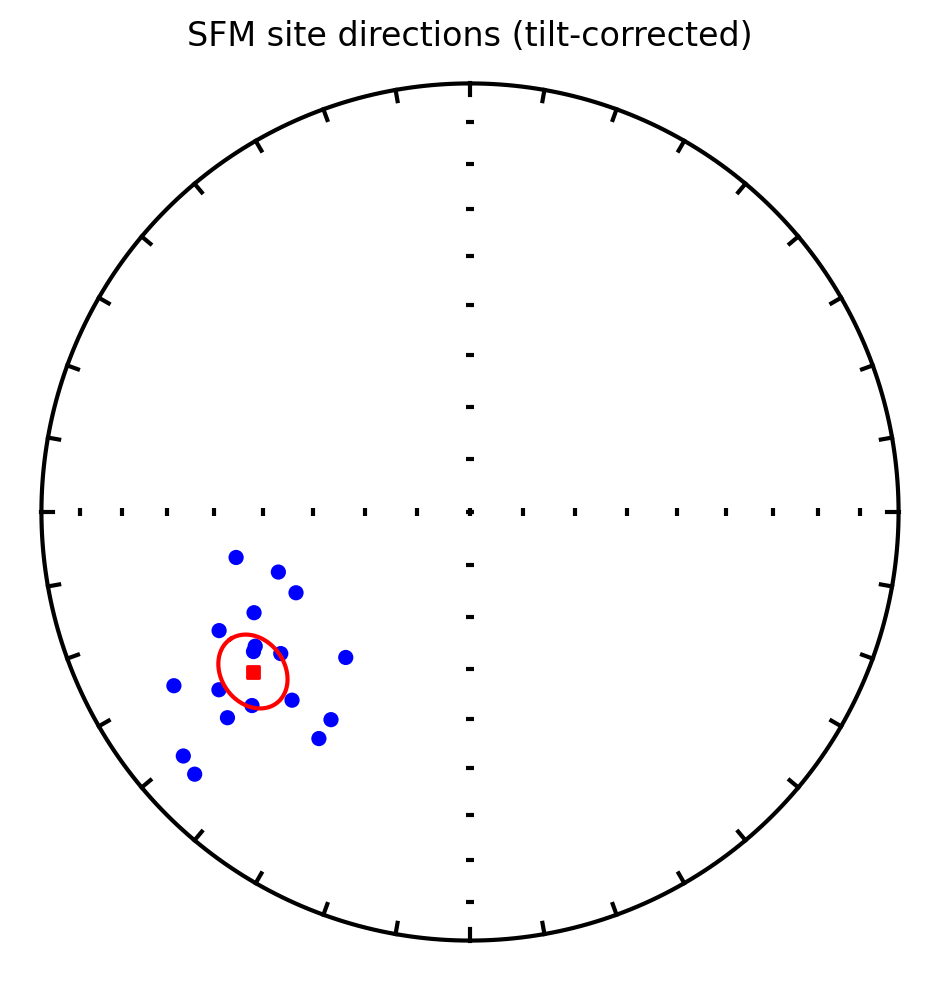

In [3]:
dir_block, dir_mean = pt.compute_mean_direction(primary, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.title('SFM site directions (tilt-corrected)')
plt.show()

## Field tests

**Fold test.** Tilting of the volcanic units accompanied caldera collapse, so a
tilt (fold) test bears on the age of the magnetization. Two tests are applied
below using the per-site bedding (`bed_dip`, `bed_dip_direction`): (1) the Fisher
precision of the 18-site mean rises from the in-situ value to the tilt-corrected
value, and (2) the bootstrap fold test of Tauxe & Watson (1994)
(`ipmag.bootstrap_fold_test`) locates the tightest grouping — the maximum of the
largest eigenvalue of the orientation matrix — close to 100% unfolding, with 95%
confidence bounds that enclose 100%. Both indicate a positive fold test (cf.
Meert & Stuckey, 2002), so the magnetization predates the caldera-collapse
tilting.

**Conglomerate test.** Clasts drilled from the overlying Cambrian boulder
conglomerate (site 6-CT) carry randomly oriented high-temperature components
(k ≈ 1, α95 ≈ 60°), a positive conglomerate test constraining the SFM
magnetization to be older than Late Cambrian.

**Inverse baked-contact test.** There is a positive inverse baked-contact test:
small mafic dikes of the younger Skrainka suite, which intrudes the ca. 1466 Ma
SFM rocks, carry — together with their immediately adjacent baked host — an
E–NE-down magnetization attributed to dike emplacement, whereas more distal host
rock retains the characteristic ca. 1466 Ma SFM direction (Meert & Stuckey,
2002). The age of this younger intrusive episode is fixed by ID-TIMS U-Pb ages
of 1323 ± 1 Ma (baddeleyite, Devil's Tollgate Gabbro of the Skrainka suite),
1323 ± 2 Ma (Munger Granite Porphyry), and 1317 ± 2 Ma (Graniteville Granite)
(Thomas et al., 2012). The test therefore shows that the older SFM remanence
survived the ca. 1320 Ma thermal event and predates it, consistent with a
primary ca. 1466 Ma cooling magnetization.

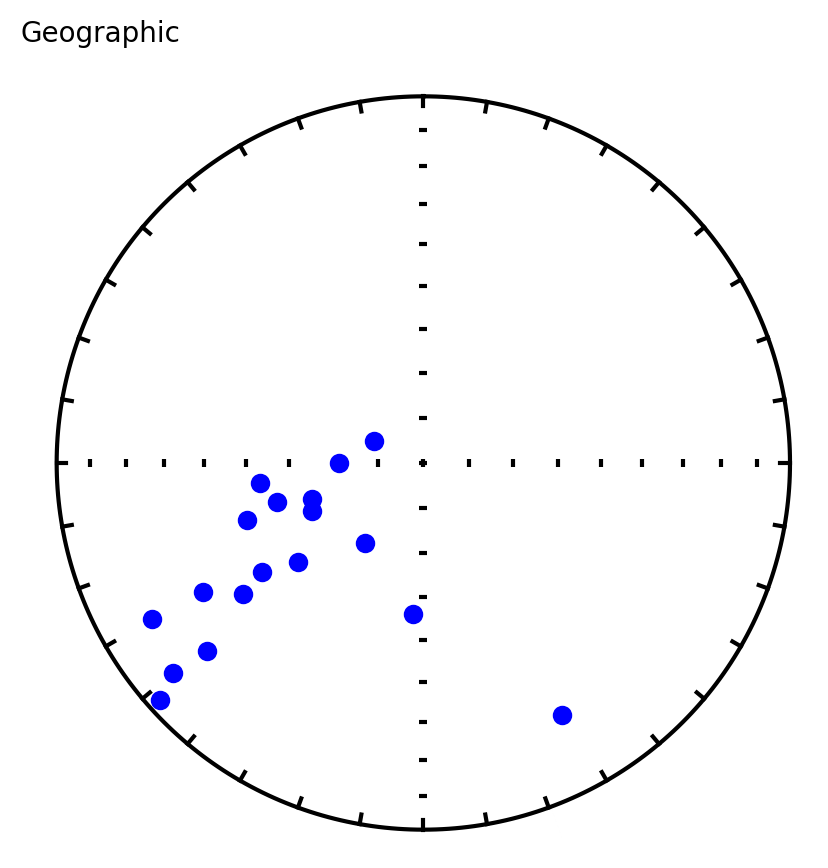

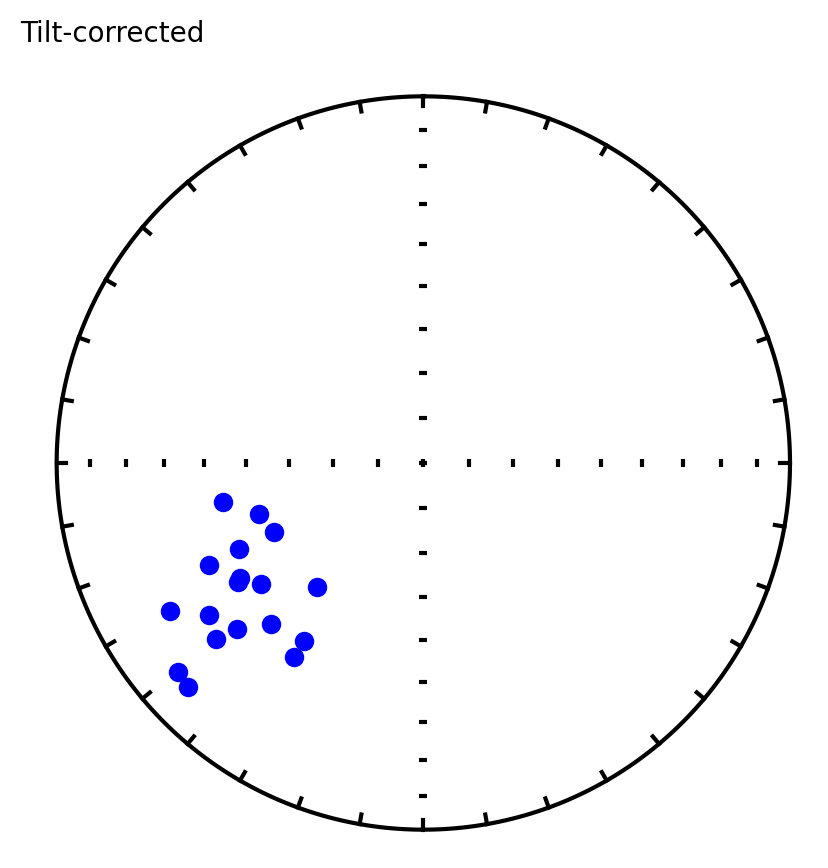

doing  1000  iterations...please be patient.....

tightest grouping of vectors obtained at (95% confidence bounds):
97 - 119 percent unfolding
range of all bootstrap samples: 
73  -  119 percent unfolding


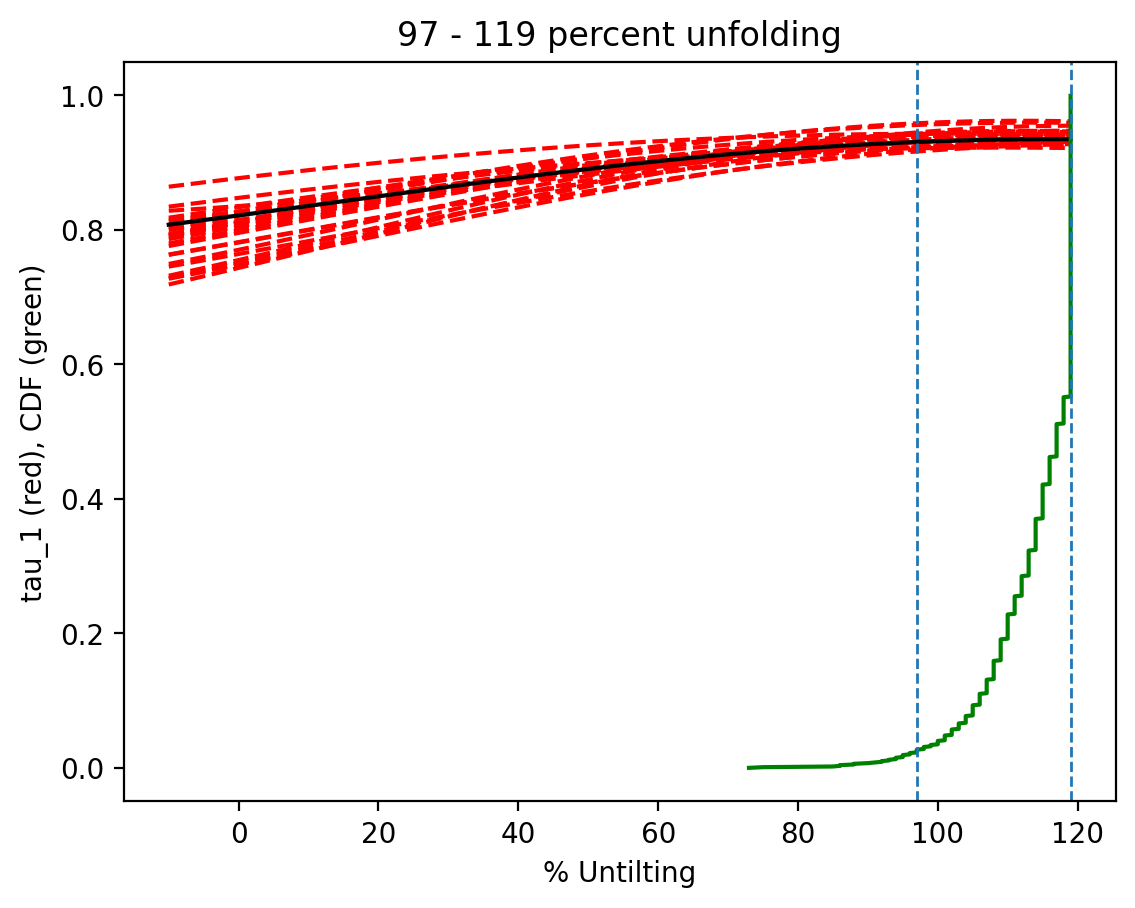

In [4]:
# bootstrap fold test (Tauxe & Watson, 1994) on the in-situ directions of the 18
# pole sites (sites_geo, loaded above), with the per-site bedding
fold_data = sites_geo[['dir_dec', 'dir_inc', 'bed_dip_direction', 'bed_dip']].values
ipmag.bootstrap_fold_test(fold_data, num_sims=1000, random_seed=23)

## Mean pole from site VGPs

The SFM direction is southwest-and-down (reversed polarity), giving a
southern-hemisphere pole; the Fisher mean is taken without polarity flipping to
preserve that convention.

Plon: 219.1  Plat: -12.1
Number of directions in mean (n): 18
Angular radius of 95% confidence (A_95): 6.0
Precision parameter (k) estimate: 33.7

Meert & Stuckey (2002) Mean-VGP: 13.2 S / 219.0 E, dp 4.7, dm 8.0, N=18


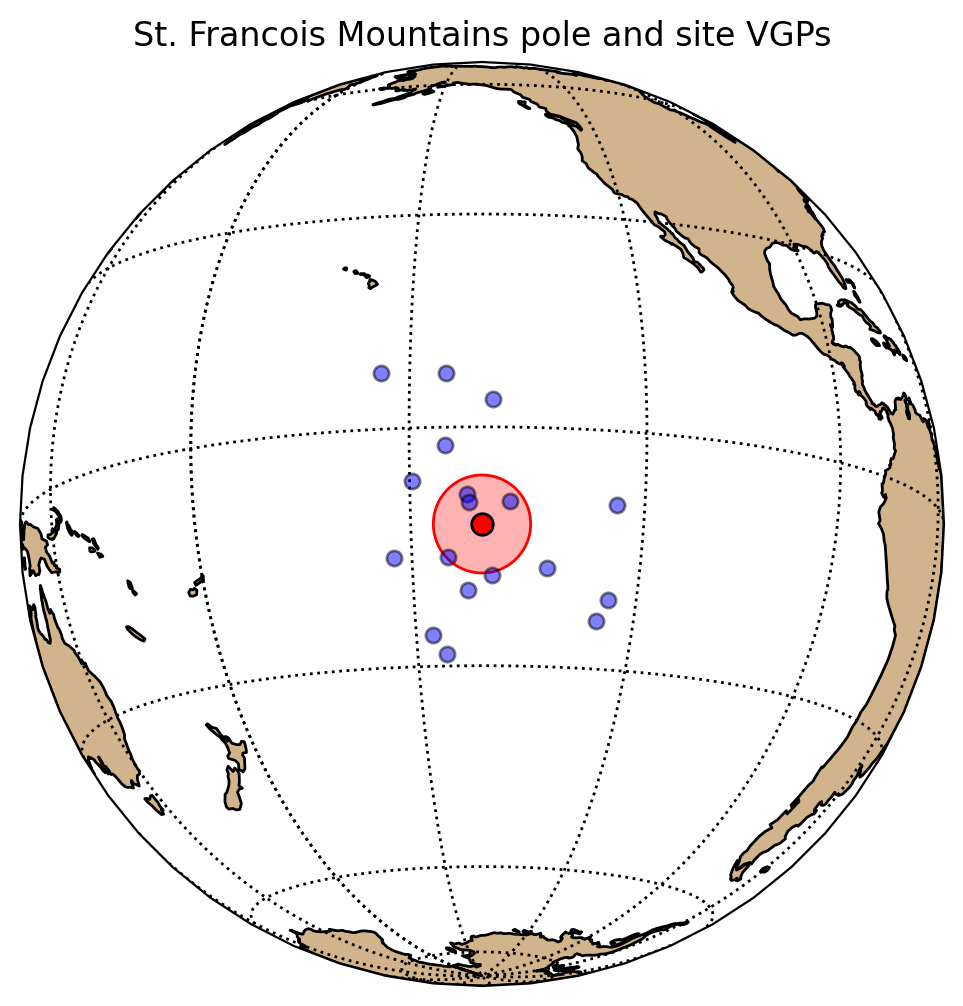

In [5]:
vgp_block, pole_mean = pt.compute_mean_pole(primary, unify_polarity=False)
ipmag.print_pole_mean(pole_mean)
print('\nMeert & Stuckey (2002) Mean-VGP: 13.2 S / 219.0 E, dp 4.7, dm 8.0, N=18')

_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('St. Francois Mountains pole and site VGPs')
plt.show()

## Paleosecular variation and VGP-shape diagnostics

A_95 of 6.0 passes Deenen et al. (2011) criteria of being between 3.8 and 13.3 for this number of sites


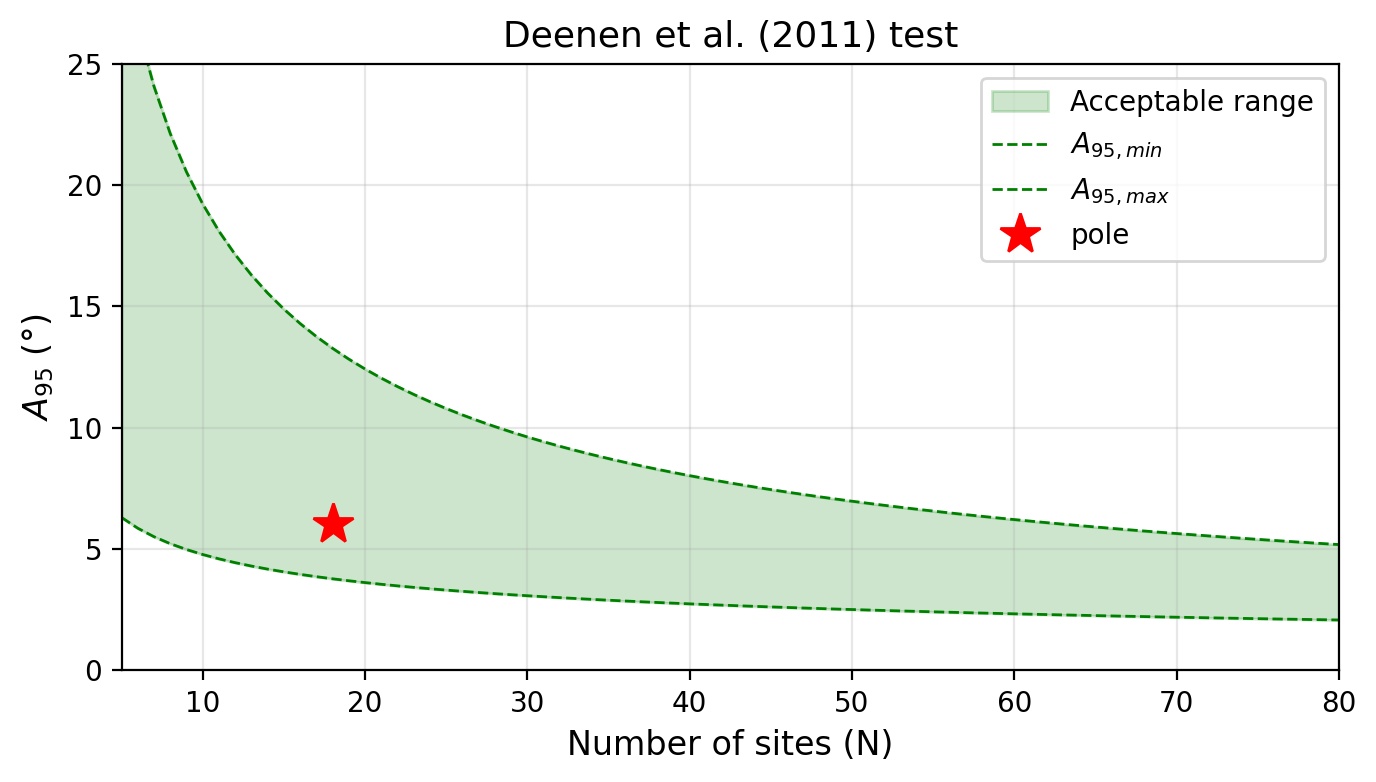

In [6]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

{'Mode': 'Mode 2',
 'Dec': -140.9444667195972,
 'Inc': -12.196905387447185,
 'N': 18,
 'Mu': 0.9068739865719839,
 'Mu_critical': 1.207,
 'Me': 0.8350354214651272,
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

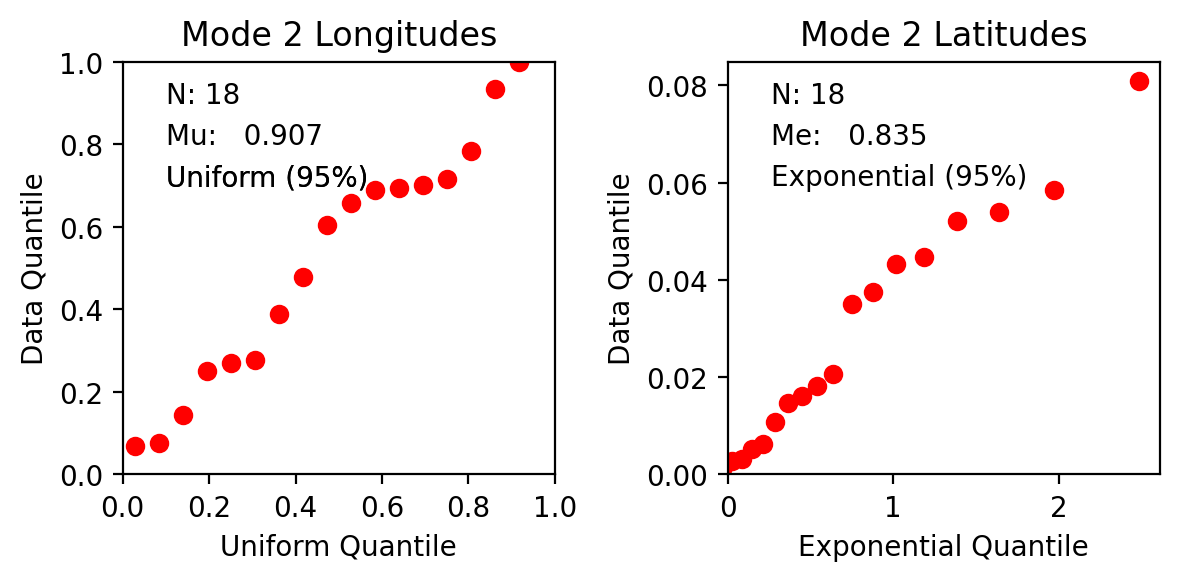

In [7]:
fishqq_result = pt.fishqq_vgps(primary, unify_polarity=False)
fishqq_result

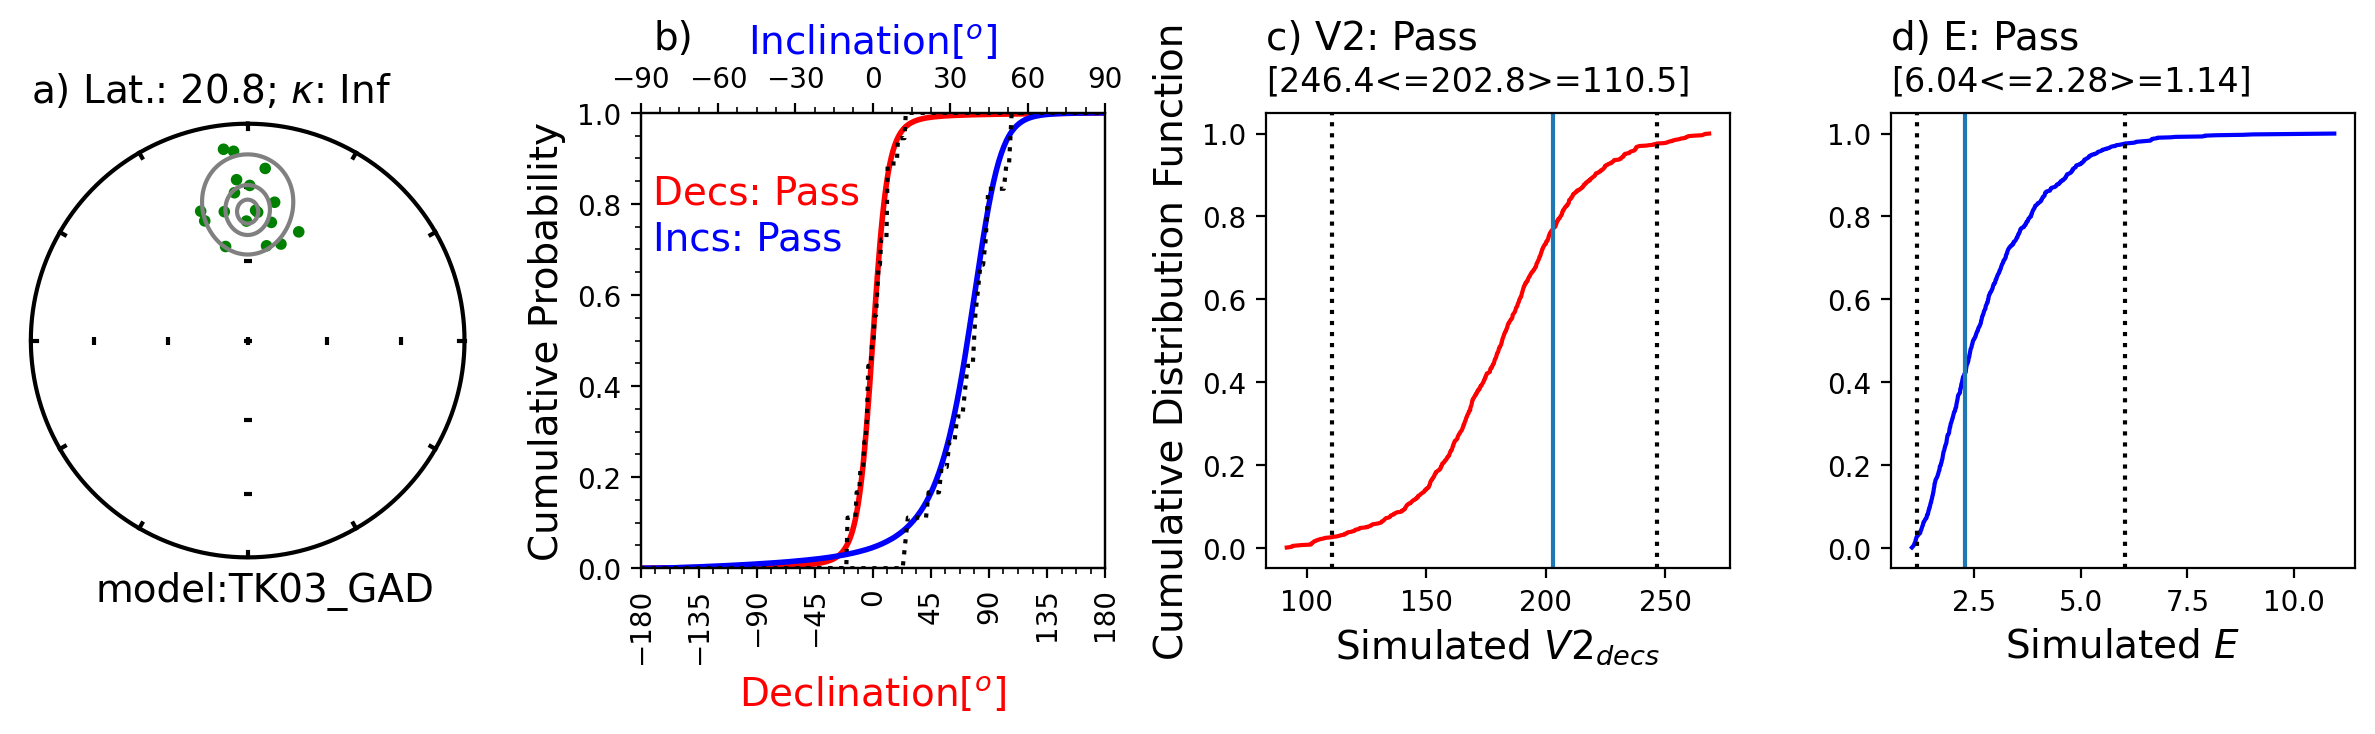

paleolatitude = 20.8 deg; elongation E = 2.28 (consistent with TK03.GAD)


In [8]:
try:
    svei_result = pt.svei_test_vgps(primary, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(primary, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The SFM pole in the context of the Laurentia APWP

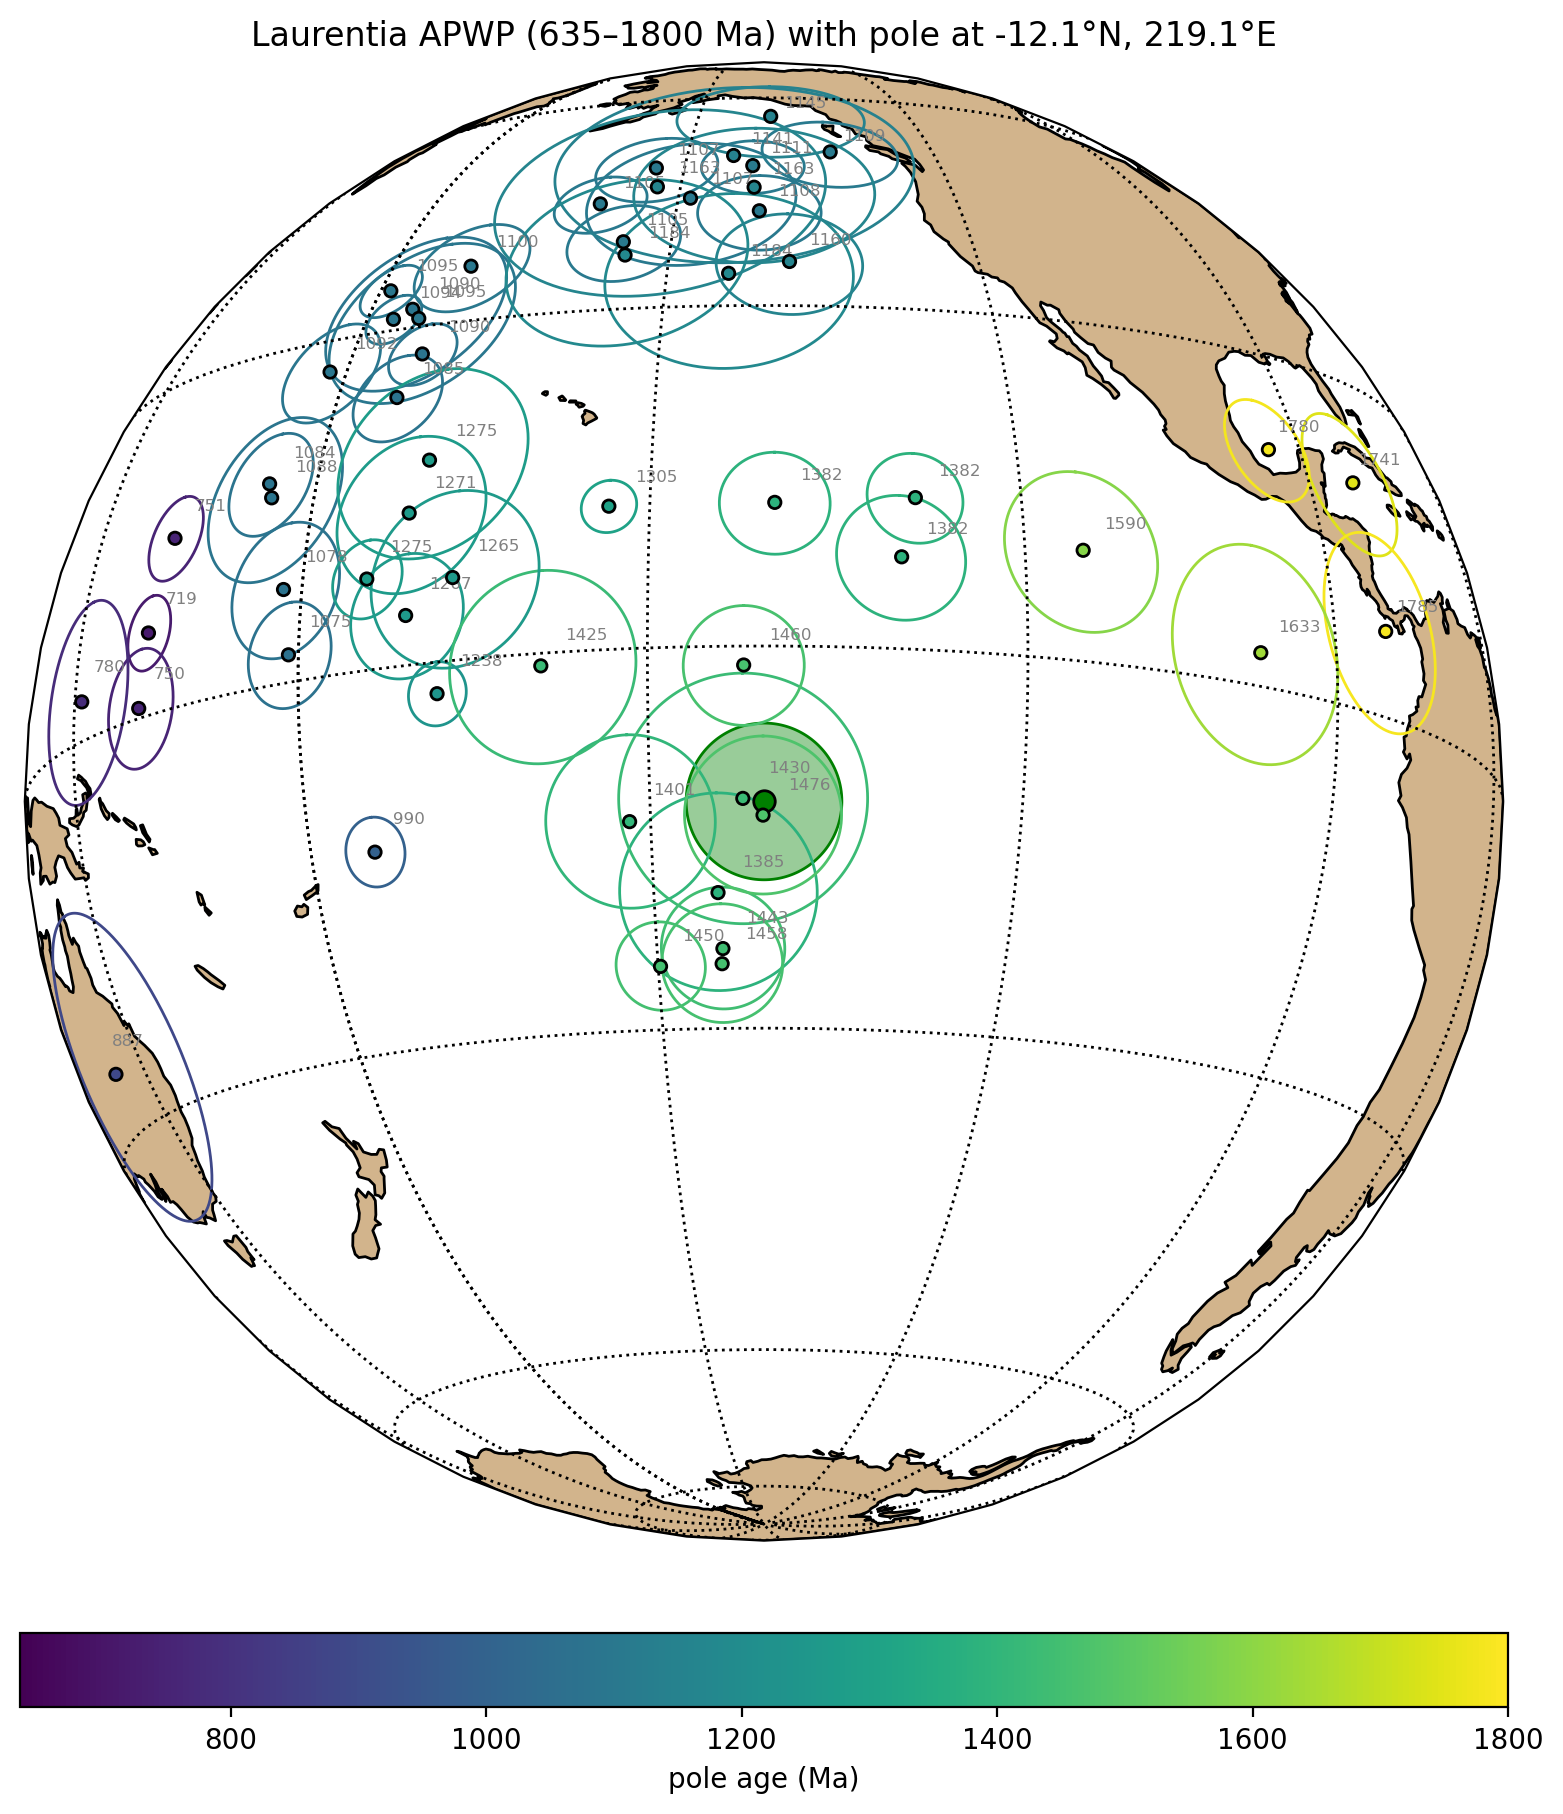

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

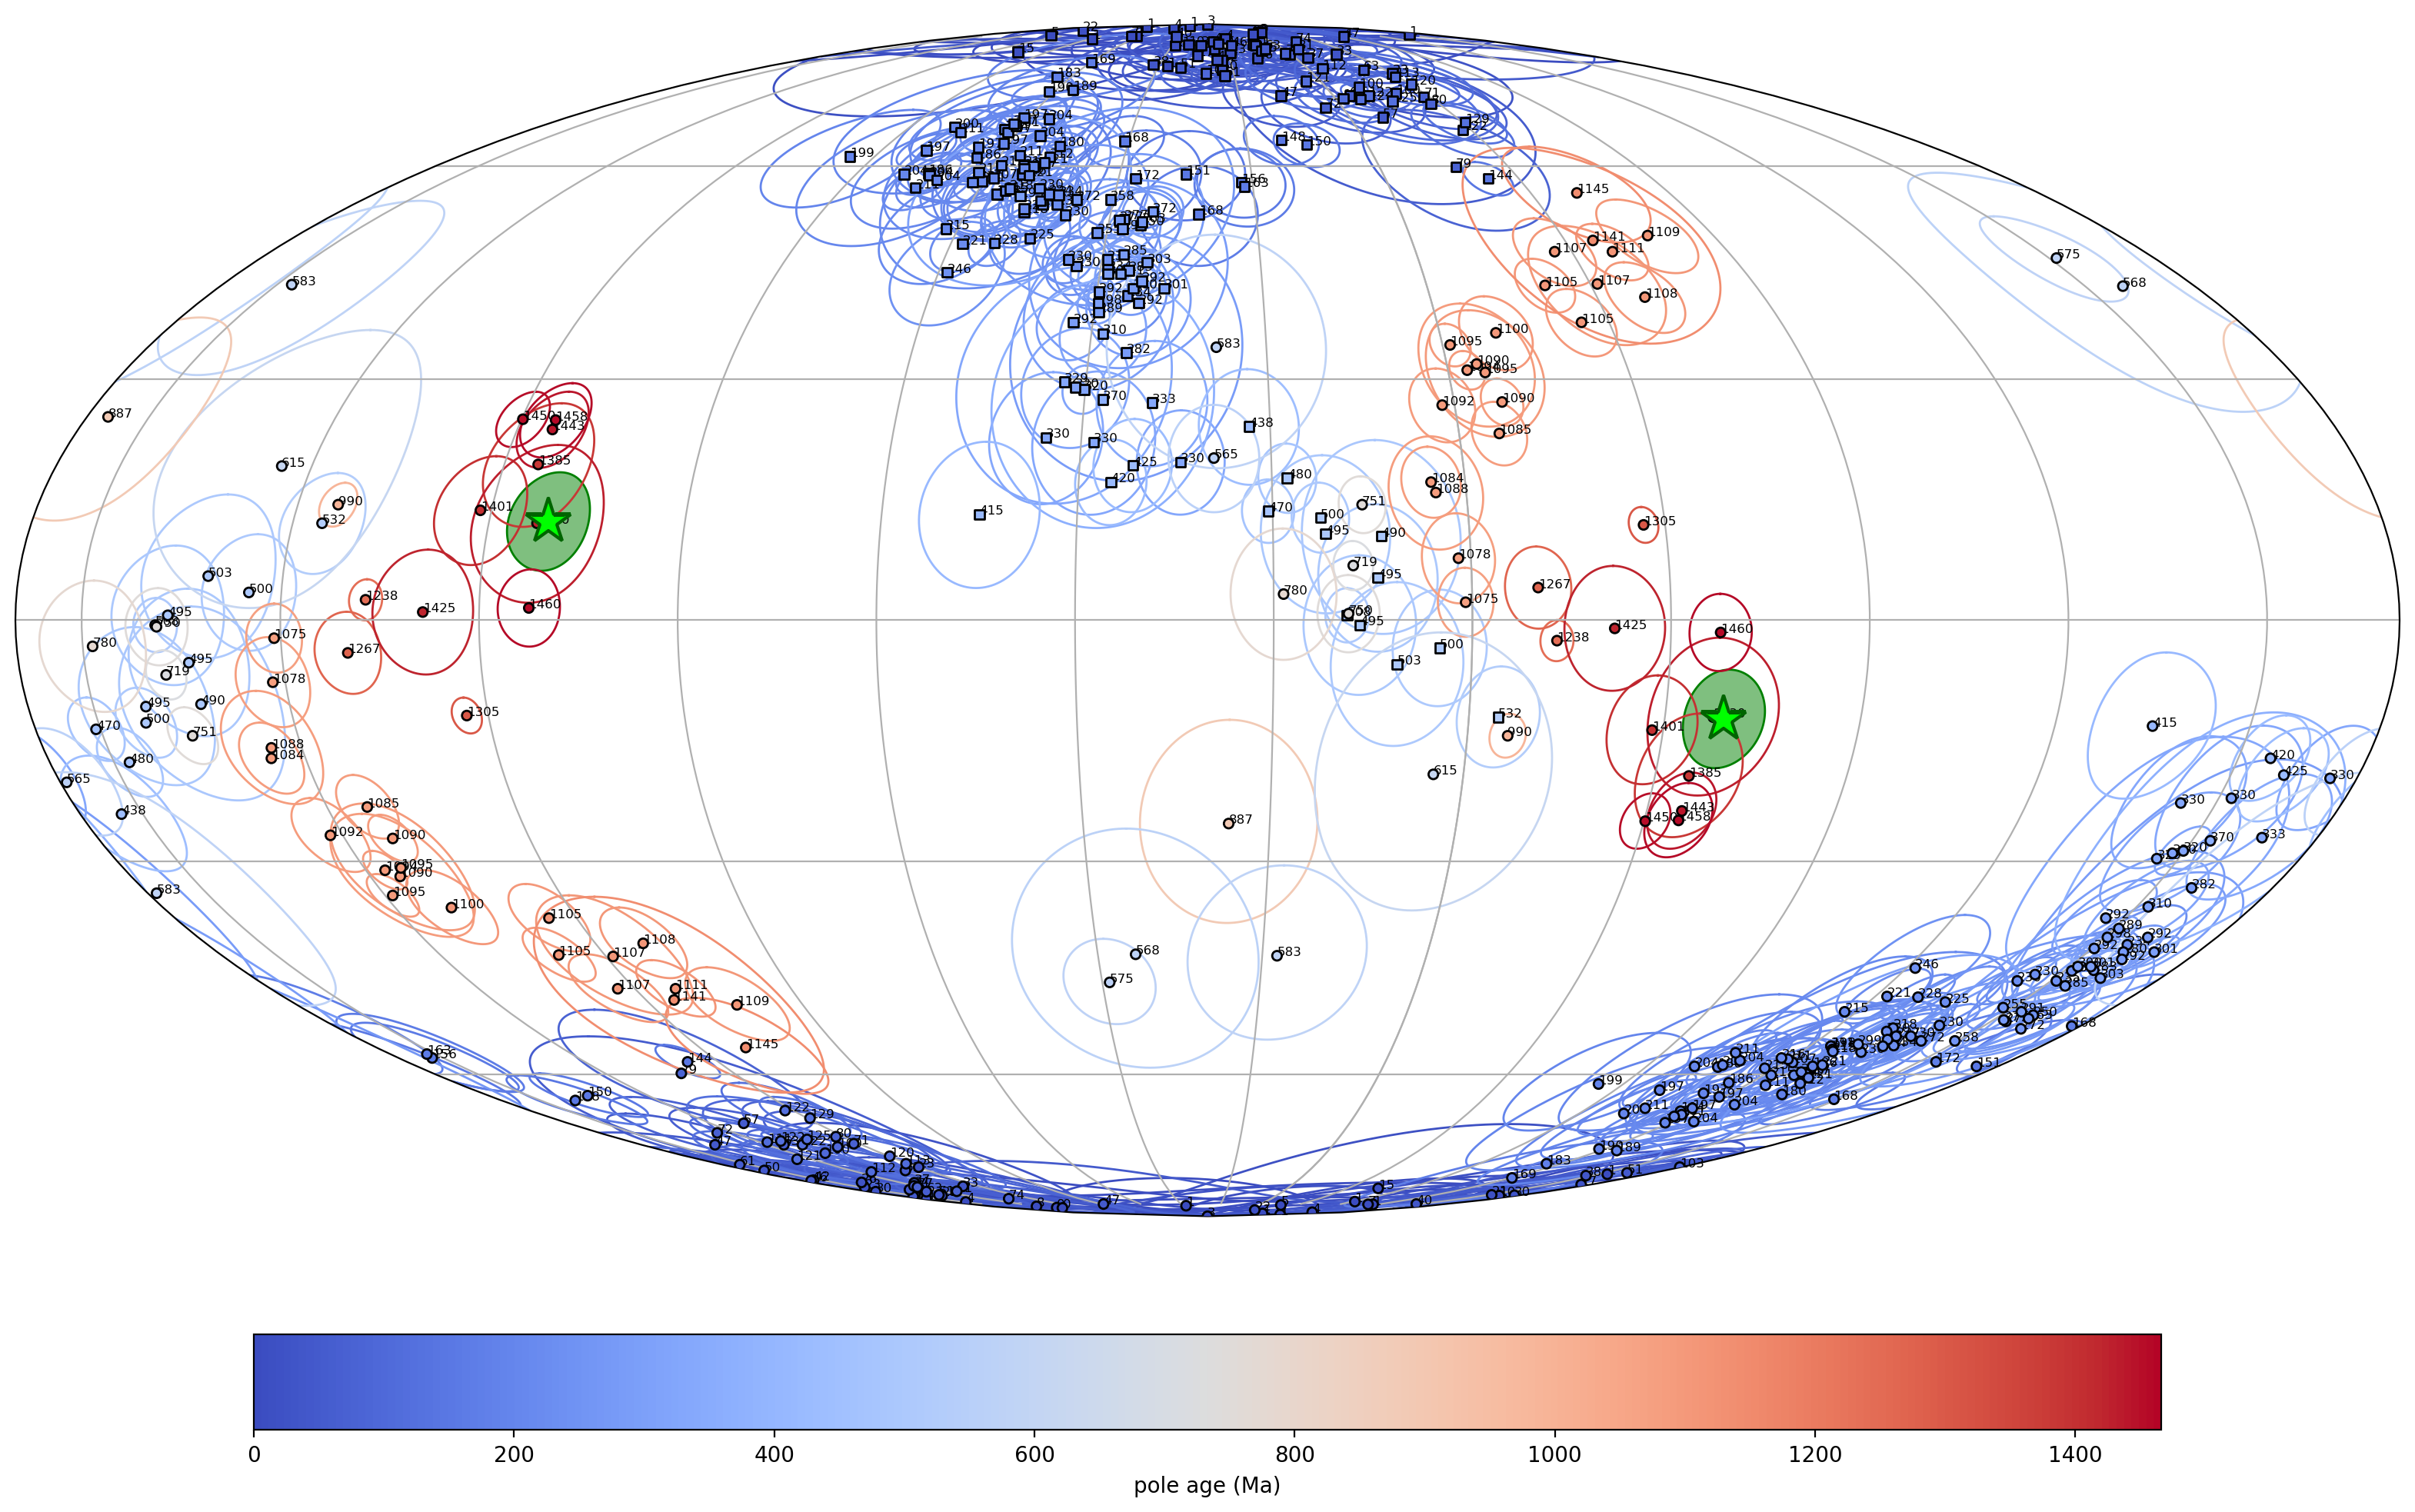

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('St. Francois Mountains', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1466)
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | U-Pb zircon and titanite assign the sampled rocks to the 1.48-1.45 Ga SFM episode (du Bray et al., 2021); the adopted 1466 Ma (1448-1484) range spans ± 18 Ma, exceeding ± 15 Ma. |
| 2 | Techniques and statistical analysis | **1** | Thermal (and AF) demagnetization with vector analysis; N = 18 site means, K = 33.7, A95 = 6.0° passes the Deenen et al. (2011) envelope. |
| 3 | Magnetic mineralogy characterized | **1** | IRM and three-axis thermal demagnetization characterize the remanence carriers (Meert & Stuckey, 2002). |
| 4 | Field tests constrain age of magnetization | **cfg** | Positive conglomerate test (Cambrian boulder conglomerate, site 6-CT), positive inverse baked-contact test (ca. 1320 Ma Skrainka-suite dikes; ID-TIMS U-Pb 1323 ± 1 to 1317 ± 2 Ma, Thomas et al., 2012), and positive fold test (caldera-collapse tilting) jointly bracket the magnetization to the ca. 1466 Ma cooling age. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous southern Laurentia; tilt-corrected for caldera-collapse tilting. |
| 6 | Presence of reversals | **0** | The accepted sites are of a single polarity (the reversed site 15 was poorly grouped and excluded). |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles; field tests independently bracket the age. |
| | Total | **5/7** | Grade A |

## Nordic workshop summary

The SFM pole is recreated at the site level from the 18 stable-direction sites of
Meert & Stuckey (2002), with signed VGPs recomputed (the source contribution
stored unsigned VGP latitudes). The recreation (−12.1°N/219.1°E, A95 6.0°)
reproduces the published Mean-VGP pole (13.2°S/219.0°E, dp 4.7°/dm 8.0°) within
its confidence ellipse. R4 records the positive conglomerate, inverse
baked-contact, and fold tests.

### Primary (characteristic) pole

| | This study (site VGPs) | Meert & Stuckey (2002) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary ChRM (tilt-corrected) | Mean-TC / Mean-VGP | Primary ChRM |
| N (sites) | 18 | 18 | 18 |
| N (specimens) | 101 | — | 103 |
| Dec (°) | 233.7 | 233.4 | 233.4 |
| Inc (°) | 37.1 | 36.9 | 36.9 |
| k (direction) | 27.7 | 27.0 | 27.0 |
| α95 (direction, °) | 6.7 | 6.8 | 6.8 |
| Pole lat (°N) | −12.1 | −13.2 | −13.2 |
| Pole lon (°E) | 219.1 | 219.0 | 219.0 |
| A95 (pole, °) | 6.0 | 6.0 | 6.1 |
| dp / dm (°) | — | 4.7 / 8.0 | 4.7 / 8.0 |

Meert & Stuckey (2002) report the tilt-corrected direction and pole as Mean-TC
(Dec 233.4°, Inc 36.9°, k 27.0, α95 6.8°; pole 13.2°S / 219.0°E, dp 4.7° /
dm 8.0°) and the corresponding VGP-mean pole as Mean-VGP (k 34.0, A95 6.0°;
12.1°S / 219.1°E), both from N = 18 sites (Table 1, p. 1007-3). The α95 6.0° and
pole 12.1°S / 219.1°E in the paper column are the Mean-VGP values; dp / dm are
the Mean-TC values. N (specimens) is not tabulated as a total in the paper.


In [11]:
sfm_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='St. Francois Mountains Acidic Rocks',
    sites=primary,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='',
    tests='C*+ (positive inverse baked-contact test, ca. 1320 Ma Skrainka-suite dikes), F+ (positive fold test, caldera tilting), G+ (positive conglomerate test, Cambrian boulder conglomerate)',
    gpmdb_number='8932',
    percent_reversed=0,
    demag_code=4,
    R1=0, R2=1, R3=1, R4='cfg', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1466, lomagage=1448, himagage=1484,
    REF_method="The SFM igneous province was originally dated at 1476 ± 16 Ma (U-Pb zircon;\nVan Schmus et al., 1993), the age adopted by Meert & Stuckey (2002). A\nsubsequent U-Pb zircon and titanite study by du Bray et al. (2021) dated many\nmore SFM units and resolved two magmatic episodes: a more voluminous, widespread\nepisode at 1.48-1.45 Ga and a younger episode at 1.34-1.27 Ga. The dolerites and\nacidic rocks carrying the paleomagnetic remanence belong to the older\n1.48-1.45 Ga episode. Taking the spread of in-situ dates from that episode gives\na nominal age of 1466 Ma with bounds of 1448-1484 Ma, adopted here in place of\nthe older 1476 ± 16 Ma value.",
    POLE_AUTHORS='Meert, J. G., & Stuckey, W.',
    YEAR=2002,
    JOURNAL='Tectonics',
    VOLUME='21',
    VPAGES='1007',
    TITLE='Revisiting the paleomagnetism of the 1.476 Ga St. Francois Mountains igneous province, Missouri',
    COMMENT='Recalculated from site VGPs as documented in Swanson-Hysell et al. 2026.'
)
pt.save_nordic_summary(sfm_summary, '1466_St_Francois_Mountains')
sfm_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,St. Francois Mountains Acidic Rocks,GPMDB:8932,,"C*+ (positive inverse baked-contact test, ca. ...",100,37.5,269.5,18,101,...,1484,The SFM igneous province was originally dated ...,St. Francois Mountains Acidic Rocks,"Meert, J. G., & Stuckey, W.",2002,Tectonics,21,1007,Revisiting the paleomagnetism of the 1.476 Ga ...,Recalculated from site VGPs as documented in S...
